# Audio Fingerprinting Pipeline: Step-by-Step Explanation and Visualization

This notebook explains the steps involved in this audio fingerprinting pipeline including:
- loading audio
- computing spectrograms
- detecting peaks
- generating fingerprints
- storing them in a database
- matching for recognition.

Visualizations are provided for each step to aid understanding.    

## 1. Import Required Libraries

In [1]:
# Import libraries for audio processing, visualization, and database operations
import matplotlib.pyplot as plt
from pathlib import Path
from audio_processing.audio import load_audio
from audio_processing.spectrogram import spectrogram, find_peaks
from controllers.database import connect, init_db
from controllers.fingerprint import generate_fingerprints
from controllers.song_manager import persist_song_data

## 2. Load Audio Files

Load WAV audio files from the specified directory using the `load_audio` function.

In [2]:
# Specify the folder containing WAV files
clean_folder = Path("data", "assets", "clean_wavs")

# Load the first audio file for demonstration
wav_paths = list(clean_folder.glob("*.wav"))
if not wav_paths:
    raise FileNotFoundError("No WAV files found in the specified directory.")

wav_path = wav_paths[0]
y, sr = load_audio(wav_path.as_posix())
print(f"Loaded {wav_path.name}, Sample Rate: {sr}, Audio Length: {len(y)/sr:.2f} seconds")

Loaded music-hd-0022.wav, Sample Rate: 22050, Audio Length: 166.45 seconds


## 3. Compute Spectrogram

Compute the spectrogram for the loaded audio file using the `spectrogram` function.

In [3]:
# Compute the spectrogram for the loaded audio
default_n_fft = 4096
default_hop_length = 512
S_db = spectrogram(y, n_fft=default_n_fft, hop_length=default_hop_length)
print(f"Spectrogram shape: {S_db.shape}")

Spectrogram shape: (2049, 7169)


## 4. Visualize Spectrogram

Display the computed spectrogram using matplotlib's `imshow` for a clear time-frequency representation.

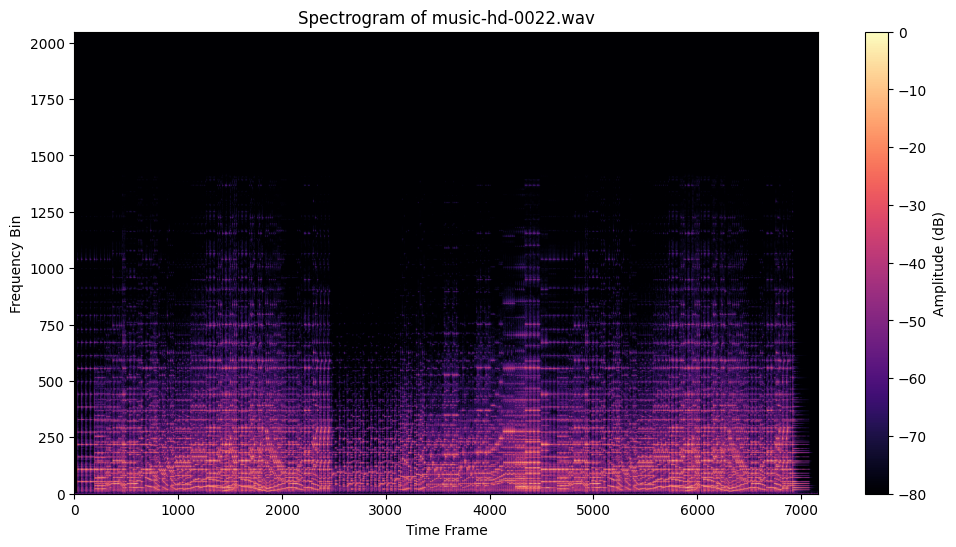

In [4]:
# Visualize the spectrogram
plt.figure(figsize=(12, 6))
plt.imshow(S_db, aspect="auto", origin="lower", cmap="magma")
plt.colorbar(label="Amplitude (dB)")
plt.title(f"Spectrogram of {wav_path.name}")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.show()

## 5. Find Spectrogram Peaks

Detect local maxima (peaks) in the spectrogram using the `find_peaks` function.

In [5]:
# Find peaks in the spectrogram
amp_min = -60  # Minimum amplitude threshold for peak detection
peaks = find_peaks(S_db, amp_min=amp_min)
print(f"Number of peaks detected: {len(peaks)}")

Number of peaks detected: 9246


## 6. Visualize Peaks on Spectrogram

Overlay the detected peaks on the spectrogram visualization using scatter plots for clarity.

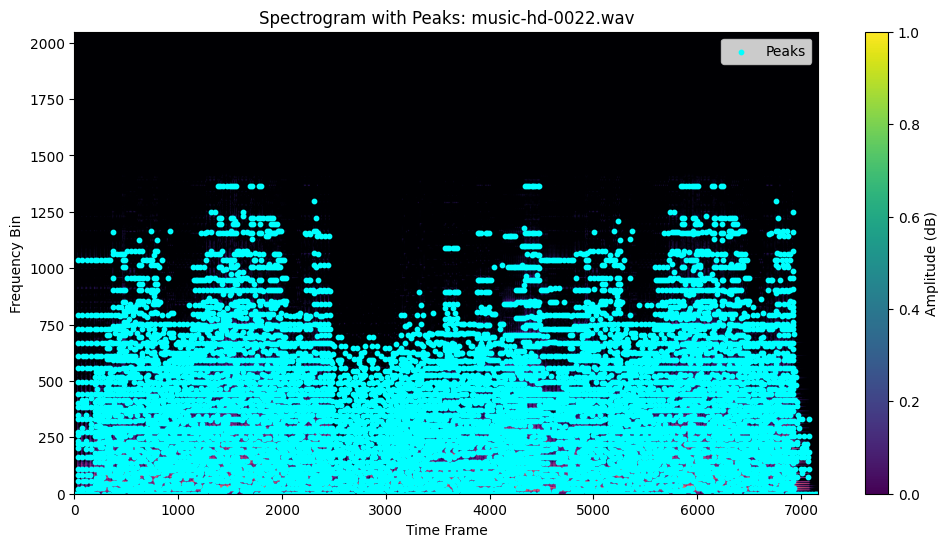

In [6]:
# Visualize peaks on the spectrogram
plt.figure(figsize=(12, 6))
plt.imshow(S_db, aspect="auto", origin="lower", cmap="magma")
if peaks:
    times, freqs = zip(*peaks)
    plt.scatter(times, freqs, s=10, c="cyan", label="Peaks")
plt.colorbar(label="Amplitude (dB)")
plt.title(f"Spectrogram with Peaks: {wav_path.name}")
plt.xlabel("Time Frame")
plt.ylabel("Frequency Bin")
plt.legend()
plt.show()

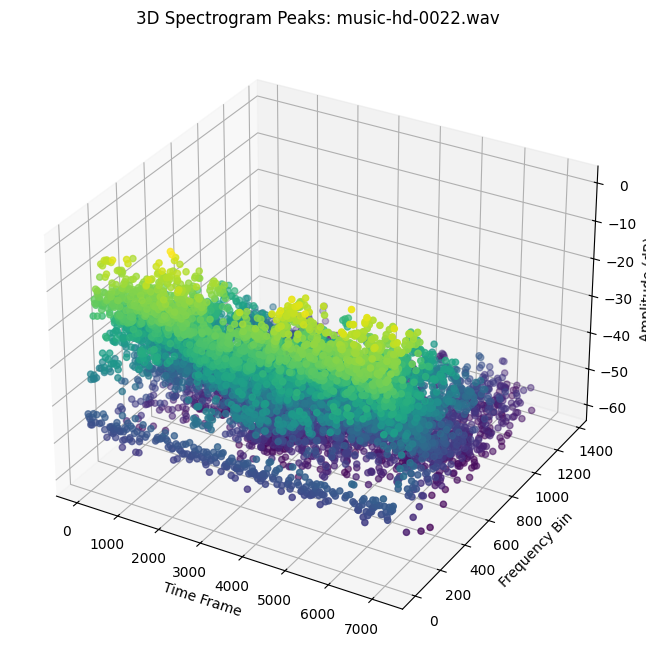

In [7]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
if peaks:
    times, freqs = zip(*peaks)
    amplitudes = S_db[freqs, times]
    ax.scatter(times, freqs, amplitudes, c=amplitudes, cmap='viridis', s=20)
ax.set_xlabel('Time Frame')
ax.set_ylabel('Frequency Bin')
ax.set_zlabel('Amplitude (dB)')
ax.set_title(f'3D Spectrogram Peaks: {wav_path.name}')
plt.show()

## 7. Generate Fingerprints from Peaks

Generate fingerprints from the detected peaks using the `generate_fingerprints` function and display some examples.

In [8]:
# Generate fingerprints from peaks
fingerprints = generate_fingerprints(peaks)
print(f"Number of fingerprints generated: {len(fingerprints)}")
# Display a few example fingerprints
print("Example fingerprints:", fingerprints[:5])

Number of fingerprints generated: 22732
Example fingerprints: [('ba598f1265790ce7911e', np.int64(9)), ('e56a3d1a60331f1a54f6', np.int64(9)), ('61e9bbc641f0ff26a404', np.int64(9)), ('f498373f6ab3082a623e', np.int64(9)), ('06b199f73163467c729d', np.int64(9))]


## 8. Persist Song Data to Database

Store the generated fingerprints in the database using the `persist_song_data` function.

In [9]:
# Store fingerprints in the database
conn = connect()
init_db(conn)
song_name = wav_path.stem
persist_song_data(conn, song_name, fingerprints)
print(f"Persisted {len(fingerprints)} fingerprints for song '{song_name}' in the database.")

Persisted 22732 fingerprints for song 'music-hd-0022' in the database.


## 9. Match Fingerprints and Display Results

Match fingerprints against the database using the `match` function and display recognition results.

In [10]:
# Optional overide fingerprints with those from mic recording

import time
from audio_processing.audio import record_audio

for i in range(3, 0, -1):
    print(f"\r--- Recording starts in {i} seconds ---")
    time.sleep(0.5)
print("Recording now...")
y_mic, sr_mic = record_audio(duration=7)
print("Recording done.")

S_db_mic = spectrogram(y_mic)
peaks_mic = find_peaks(S_db_mic)
fps_mic = generate_fingerprints(peaks_mic)
print(f"Mic clip: {len(peaks_mic)} peaks, {len(fps_mic)} fingerprints")

fingerprints = fps_mic


--- Recording starts in 3 seconds ---
--- Recording starts in 2 seconds ---
--- Recording starts in 1 seconds ---
Recording now...
Recording done.
Mic clip: 415 peaks, 2946 fingerprints


In [11]:
# Match fingerprints against the database and display results
import controllers.match_service

match_service = controllers.match_service.MatchService()
match_service.conn = conn
result = match_service.match_fingerprints(fingerprints)
if result:
    top_song, top_score = result
    print(f"Recognition results, top match is: {top_song} (score: {top_score})")
else:
    print("No match found.")

Recognizing audio from 2946 fingerprints...

Total songs in DB: 4

Best match: music-hd-0022 with score 188

Recognition results, top match is: music-hd-0022 (score: 188)


Min offset difference (seconds): 0.13931972789115646


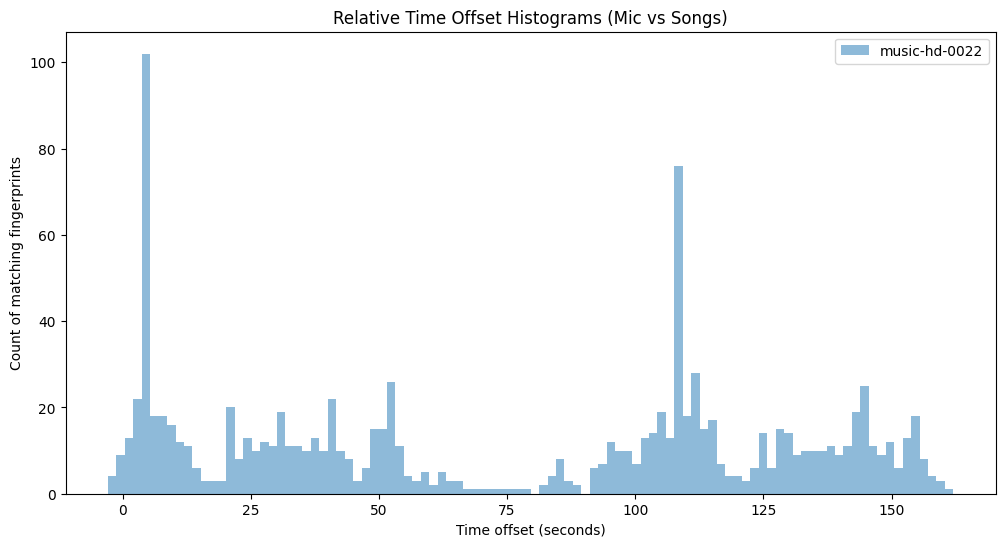

In [12]:
offset_histograms = {}


matches = []
cur = conn.cursor()
for h, offset in fingerprints:
    cur.execute("SELECT offset FROM fingerprints WHERE hash=? AND song_id=(SELECT id FROM songs WHERE name=?)", (h, top_song))
    for (db_offset,) in cur.fetchall():
        matches.append(db_offset - offset)
offset_histograms[top_song] = matches


# Convert offsets from frames to seconds
hop_length = default_hop_length  # use the same hop_length as in spectrogram
offset_histograms_seconds = {}
for song_id, offsets in offset_histograms.items():
    offsets_sec = [offset * hop_length / sr for offset in offsets]
    offset_histograms_seconds[song_id] = offsets_sec


plt.figure(figsize=(12, 6))
for song_id, offsets_sec in offset_histograms_seconds.items():
    if offsets_sec:
        plt.hist(offsets_sec, bins=100, alpha=0.5, label=song_id)


plt.title("Relative Time Offset Histograms (Mic vs Songs)")
plt.xlabel("Time offset (seconds)")
plt.ylabel("Count of matching fingerprints")
plt.legend()
#print min offset difference
print("Min offset difference (seconds):", min(abs(offset) for offsets in offset_histograms_seconds.values() for offset in offsets))

plt.show()

# Resources:

- [How Shazam Works (Probably!) - Computerphile](https://www.youtube.com/watch?v=RRsq9apr5QY)

- [But what is the Fourier Transform? A visual introduction.](https://www.youtube.com/watch?v=spUNpyF58BY)

- [Discrete Fourier Transform - Simple Step by Step
](https://www.youtube.com/watch?v=mkGsMWi_j4Q)

